In [1]:
#import sys
#!{sys.executable} -m pip install --user numpy==1.26.4 pandas==2.2.2 joblib==1.3.2 threadpoolctl==3.2.0 scikit-learn==1.4.2 shap==0.45.1 opencv-python==4.9.0.80

In [2]:
#python -c "import numpy, pandas, sklearn, shap, cv2, joblib; print(numpy.__version__, pandas.__version__, sklearn.__version__, shap.__version__, cv2.__version__, joblib.__version__)"

In [9]:
import pandas as pd
import numpy as np

# Cargar datasets
train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")

# Definición de datos para entrenamiento y validación

X_train_raw = train_df['Headline_Text']
X_test_raw = test_df['Headline_Text']

y_train = train_df['Category']
y_test = test_df['Category']


In [10]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('stopwords')
from nltk.corpus import stopwords

spanish_stopwords = stopwords.words('spanish')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lendg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
# Vectorización

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    sublinear_tf=True,
    stop_words=spanish_stopwords   # elimina stopwords en español
)

X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)


In [12]:
# Modelo SVM
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)


In [13]:
# Validación cruzada - grid search Métrica: F1 macro (balancear)

param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5],
    'loss': ['hinge', 'squared_hinge']
}


In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    svm,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)


In [15]:
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Mejores hiperparámetros:", grid.best_params_)


Mejores hiperparámetros: {'C': 0.5, 'loss': 'squared_hinge'}


Evaluación inicial SVM (umbral estándar)
Matriz de confusión:
 [[519  34]
 [ 19 106]]
Exactitud (Accuracy): 0.9218289085545722

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9647    0.9385    0.9514       553
        True     0.7571    0.8480    0.8000       125

    accuracy                         0.9218       678
   macro avg     0.8609    0.8933    0.8757       678
weighted avg     0.9264    0.9218    0.9235       678


ROC-AUC: 0.9655

Umbral óptimo según F1: -0.1151


Aplicando umbral ajustado: 100%|█████████████████████████████████████████████████| 678/678 [00:00<00:00, 361017.91it/s]



Evaluación con umbral ajustado SVM
Matriz de confusión:
 [[509  44]
 [ 10 115]]
Exactitud (Accuracy): 0.9203539823008849

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9807    0.9204    0.9496       553
        True     0.7233    0.9200    0.8099       125

    accuracy                         0.9204       678
   macro avg     0.8520    0.9202    0.8797       678
weighted avg     0.9333    0.9204    0.9239       678


ROC-AUC: 0.9655


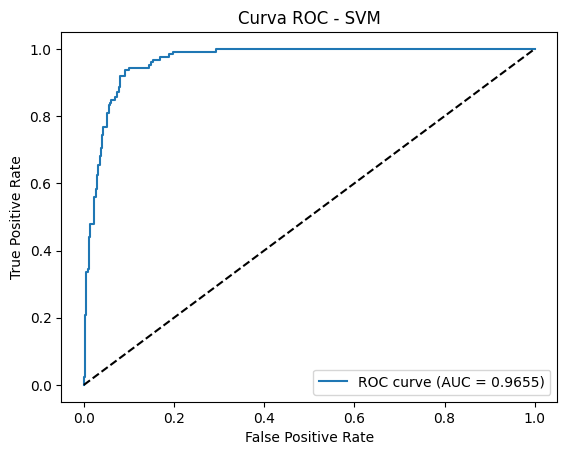

In [20]:
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Evaluación estándar (umbral implícito en predict)
y_pred = best_model.predict(X_test)

print("Evaluación inicial SVM (umbral estándar)")
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["False","True"], digits=4))

roc_auc = roc_auc_score(y_test, scores)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Evaluación ajustada con curva Precision-Recall
scores = best_model.decision_function(X_test)  # valores de margen
precisions, recalls, thresholds = precision_recall_curve(y_test, scores)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print("\nUmbral óptimo según F1:", best_threshold)

# Aplicar umbral óptimo
y_pred_custom = (scores >= best_threshold).astype(int)
cm_custom = confusion_matrix(y_test, y_pred_custom)
print("\nEvaluación con umbral ajustado SVM")
print("Matriz de confusión:\n", cm_custom)
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_custom))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_custom, target_names=["False","True"], digits=4))


print(f"\nROC-AUC: {roc_auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, scores)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM")
plt.legend(loc="lower right")

# Guardar imagen en archivo PNG
plt.savefig("curva_roc_svm.png", dpi=300, bbox_inches="tight")

# Mostrar en pantalla
plt.show()


In [18]:
import joblib

joblib.dump(best_model, "svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']